## Array Rearrangement Dataset Acquisition

Import libraries

In [1]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.imagemX2 import ImagEMX2Camera
from pytweezer.drivers.slm import SLM
from pytweezer.drivers.thorcam import ThorCamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis as an
import numpy as np
import matplotlib.pyplot as plt

ExpParams = ExpParameterManager()

Initialise and configure devices

In [2]:
exp : MotMasterClient = MotMasterClient()
motcam : ThorCamera = ThorCamera(id="motcam")
slm : SLM = SLM()
hamcam : ImagEMX2Camera = ImagEMX2Camera()

Rb MotMasterClient initialised.
Thorlabs TLCamera - motcam - initialised.
SLM 1 initialised: 1024x1024 @ 8-bit, serial 7752, 40.200 degC
SLM 1 loaded LUT "C:\Program Files\Meadowlark Optics\Blink Plus\LUT Files\slm40_at852.LUT"
ImagEM X2 camera initialised.


In [3]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")

motcam.set_trigger_source("bulb")

hamcam.set_trigger_source("ext")
hamcam.set_external_exposure_mode()
hamcam.enable_em_gain(True)
hamcam.enable_direct_em_gain(True)
hamcam.set_sensitivity(600)
hamcam.timeout = 60*20
X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
hamcam.set_roi(X0, WIDTH, Y0, HEIGHT)

## Generate Initial and Final Array Hologram

In [4]:
dx, dy = 8.0, 12.0
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40+dx, -8+dy),
                 zernike_coeff_dict={5:1.195, 6:0.725, 7:0.970, 8:0.478, 9:-1.091, 10:0.303, 11:0.021, 12:0.072, 13:0.049})

gauss2d = lambda x, y, A, x0, y0, sx, sy, offset: (A * np.exp(-(((x - x0) ** 2) / (2 * sx ** 2) + ((y - y0) ** 2) / (2 * sy ** 2)))) + offset
A, x0, y0, sx, sy, offset = [-2.14197604e+03, -1.11443850e+01 - dx, 2.09919600e+00 - dy, 2.95002910e+03, 2.64281503e+03, 2.14239505e+03]

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (48.0, 4.0) um


Initial array

In [5]:
W1 = np.ones((10,10))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W1, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W1 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms1 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array1, terms1, _ = PM.superposition_optimization(terms1, max_iter=2000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 10x10
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 1.70e-05 | Uniformity: 50.22% | Min/Max ratio: 0.077
Iteration 010 | Mean-Squared Error: 9.94e-08 | Uniformity: 82.66% | Min/Max ratio: 0.493
Iteration 020 | Mean-Squared Error: 3.59e-08 | Uniformity: 83.17% | Min/Max ratio: 0.506
Iteration 030 | Mean-Squared Error: 1.33e-08 | Uniformity: 83.64% | Min/Max ratio: 0.523
Iteration 040 | Mean-Squared Error: 1.38e-08 | Uniformity: 83.65% | Min/Max ratio: 0.535
Iteration 050 | Mean-Squared Error: 7.98e-09 | Uniformity: 83.59% | Min/Max ratio: 0.526
Iteration 060 | Mean-Squared Error: 3.14e-09 | Uniformity: 83.70% | Min/Max ratio: 0.534
Iteration 070 | Mean-Squared Error: 9.77e-10 | Uniformity: 83.68% | Min/Max ratio: 0.534
Iteration 080 | Mean-Squared Error: 5.32e-10 | Uniformity: 83.62% | Min/Max ratio: 0.532
Iteration 090 | Mean-Squared Error: 1.24e-09 | Uniformity: 83.57% | Min/Max ratio: 0.530
Itera

Final array

In [6]:
W2 = np.ones((7,7))
spacing_um = 5.0

w_n, theta_n, x_n, y_n, array_shape = PM.generate_weighted_array(W2, spacing_um, init_phase_randomness=1.0, angle_deg=2.5)
w_n = (W2 * gauss2d(x_n.reshape(array_shape), y_n.reshape(array_shape), A, x0, y0, sx, sy, offset)).flatten()

terms2 = [w_n, theta_n, x_n, y_n, array_shape]
pm_array2, terms2, _ = PM.superposition_optimization(terms2, max_iter=5000, damping=0.5, verbose=True)

--- Target Generation ---
Grid: 7x7
Spacing: 5.0 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 000 | Mean-Squared Error: 6.08e-05 | Uniformity: 57.07% | Min/Max ratio: 0.132
Iteration 010 | Mean-Squared Error: 6.04e-07 | Uniformity: 87.45% | Min/Max ratio: 0.628
Iteration 020 | Mean-Squared Error: 4.24e-08 | Uniformity: 88.31% | Min/Max ratio: 0.652
Iteration 030 | Mean-Squared Error: 5.61e-08 | Uniformity: 87.99% | Min/Max ratio: 0.631
Iteration 040 | Mean-Squared Error: 4.86e-09 | Uniformity: 88.25% | Min/Max ratio: 0.643
Iteration 050 | Mean-Squared Error: 1.13e-09 | Uniformity: 88.37% | Min/Max ratio: 0.644
Iteration 060 | Mean-Squared Error: 8.80e-10 | Uniformity: 88.39% | Min/Max ratio: 0.644
Iteration 070 | Mean-Squared Error: 8.39e-10 | Uniformity: 88.40% | Min/Max ratio: 0.644
Iteration 080 | Mean-Squared Error: 8.89e-10 | Uniformity: 88.40% | Min/Max ratio: 0.644
Iteration 090 | Mean-Squared Error: 1.09e-09 | Uniformity: 88.41% | Min/Max ratio: 0.644
Iterati

Load initial array onto the SLM

In [7]:
pm_composite = PM.superimpose([pm_array1, PM.fresnel, PM.blaze, PM.zernike])
pm_composite_uint8 = PM.transform_phase_8bit(pm_composite).get()
slm.update_mask(pm_composite_uint8)

## Baseline - Load and Image Initial Array

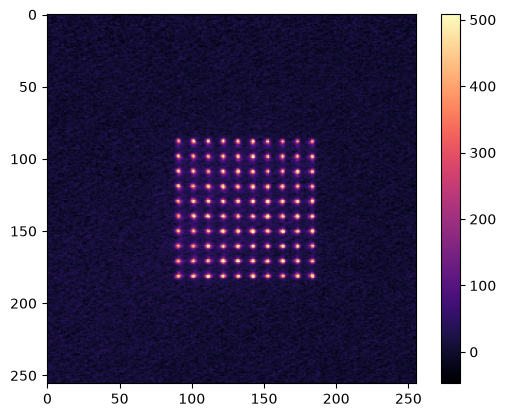

In [11]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 1})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]
img_average = an.tweezer_show_bg_subtracted(imgs1, imgs2, cmap='magma', show=True, vmaxfactor=0.6, show_grid=True)

Looking for trap sites...
10x10 array detected.


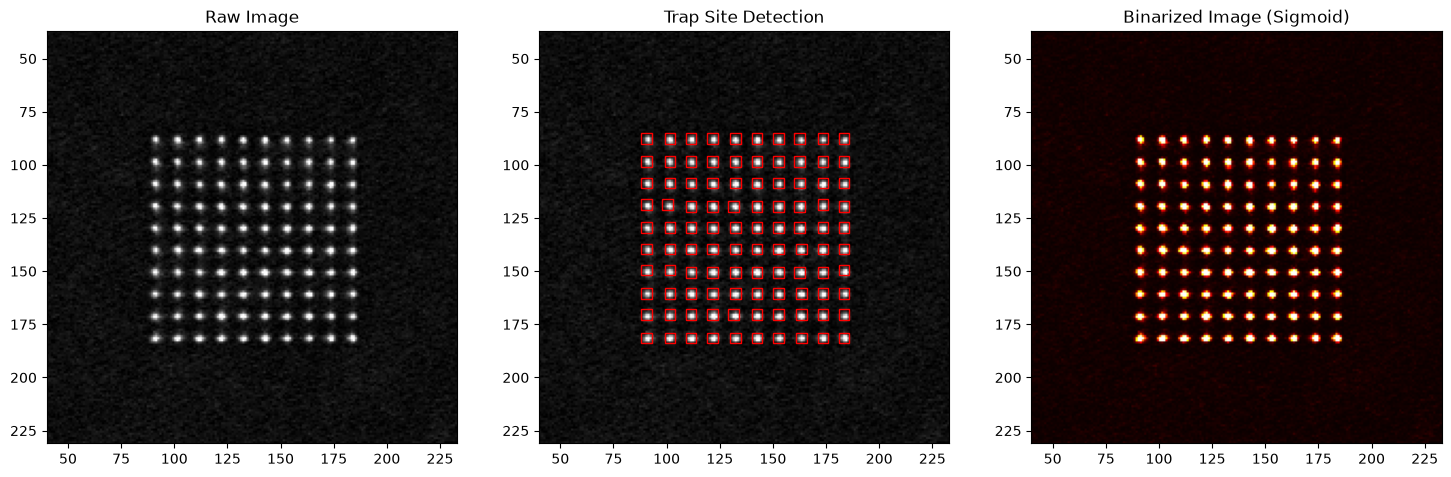

Trap (0, 0) Loading Probability : 61.00 %
Trap (0, 1) Loading Probability : 60.00 %
Trap (0, 2) Loading Probability : 55.00 %
Trap (0, 3) Loading Probability : 58.00 %
Trap (0, 4) Loading Probability : 54.00 %
Trap (0, 5) Loading Probability : 58.00 %
Trap (0, 6) Loading Probability : 50.00 %
Trap (0, 7) Loading Probability : 50.00 %
Trap (0, 8) Loading Probability : 43.00 %
Trap (0, 9) Loading Probability : 56.00 %
Trap (1, 0) Loading Probability : 59.00 %
Trap (1, 1) Loading Probability : 59.00 %
Trap (1, 2) Loading Probability : 54.00 %
Trap (1, 3) Loading Probability : 56.00 %
Trap (1, 4) Loading Probability : 59.00 %
Trap (1, 5) Loading Probability : 63.00 %
Trap (1, 6) Loading Probability : 51.00 %
Trap (1, 7) Loading Probability : 52.00 %
Trap (1, 8) Loading Probability : 56.00 %
Trap (1, 9) Loading Probability : 53.00 %
Trap (2, 0) Loading Probability : 59.00 %
Trap (2, 1) Loading Probability : 66.00 %
Trap (2, 2) Loading Probability : 47.00 %
Trap (2, 3) Loading Probability : 

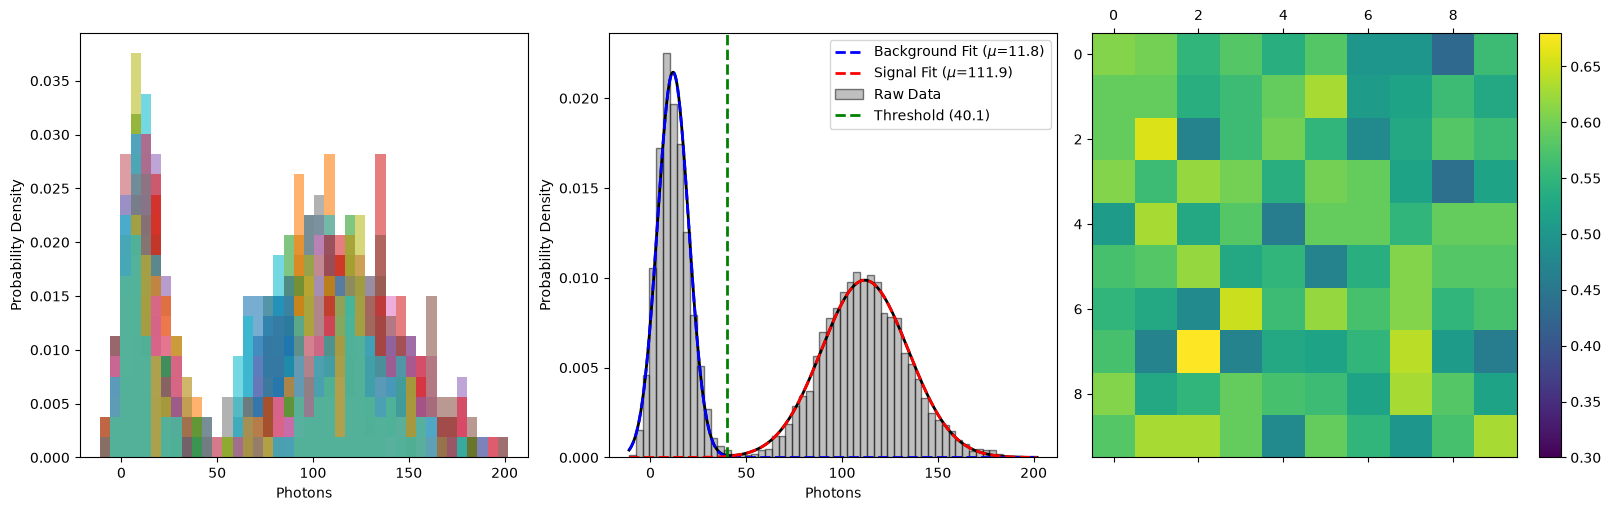

In [12]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

filtered_img_average = an.morphological_tophat_high_pass(img_average, feature_size=feature_size)
grid_positions_1, detection_threshold = an.detect_trap_sites(filtered_img_average, array_shape_1, detection_step=200)
imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
an.visualize_results(filtered_img_average, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60)

Trap (0, 0) Loading Probability : 61.00 %
Trap (0, 1) Loading Probability : 60.00 %
Trap (0, 2) Loading Probability : 55.00 %
Trap (0, 3) Loading Probability : 58.00 %
Trap (0, 4) Loading Probability : 54.00 %
Trap (0, 5) Loading Probability : 58.00 %
Trap (0, 6) Loading Probability : 51.00 %
Trap (0, 7) Loading Probability : 50.00 %
Trap (0, 8) Loading Probability : 44.00 %
Trap (0, 9) Loading Probability : 56.00 %
Trap (1, 0) Loading Probability : 59.00 %
Trap (1, 1) Loading Probability : 59.00 %
Trap (1, 2) Loading Probability : 54.00 %
Trap (1, 3) Loading Probability : 57.00 %
Trap (1, 4) Loading Probability : 59.00 %
Trap (1, 5) Loading Probability : 63.00 %
Trap (1, 6) Loading Probability : 51.00 %
Trap (1, 7) Loading Probability : 52.00 %
Trap (1, 8) Loading Probability : 56.00 %
Trap (1, 9) Loading Probability : 53.00 %
Trap (2, 0) Loading Probability : 59.00 %
Trap (2, 1) Loading Probability : 64.00 %
Trap (2, 2) Loading Probability : 47.00 %
Trap (2, 3) Loading Probability : 

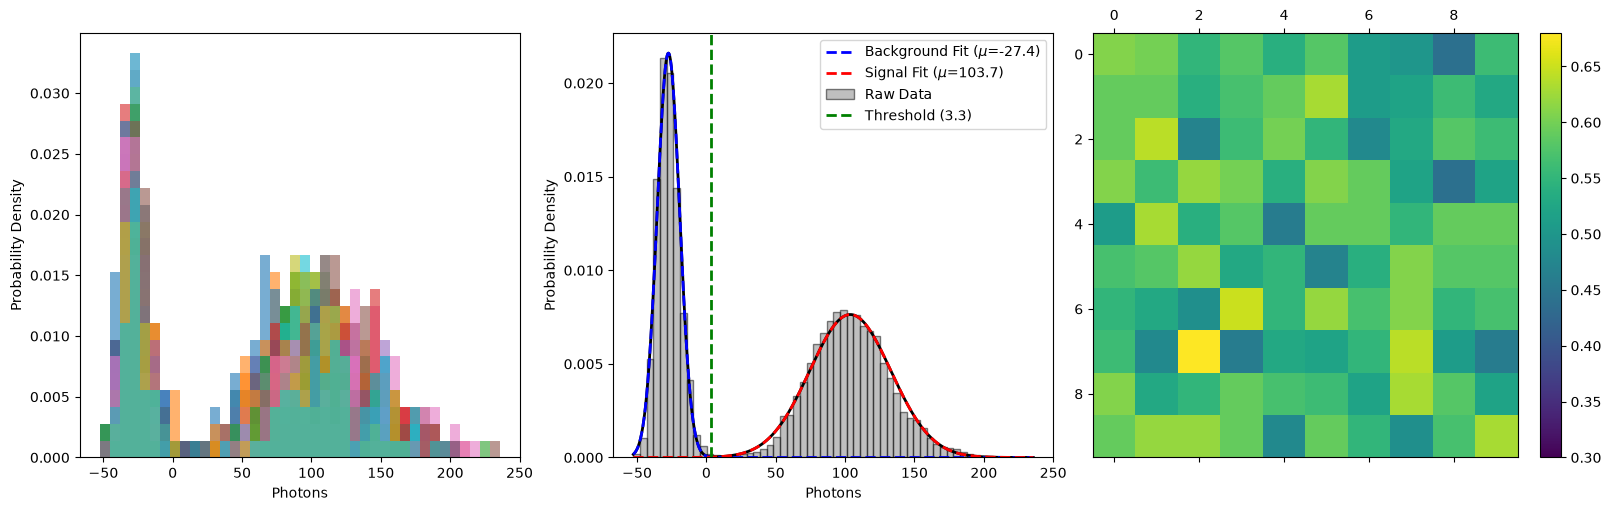

In [13]:
psf_window = 9

# Templates come from the raw frames - the matched filter needs no top-hat.
scorer = an.SiteScorer.from_images(imgs1, grid_positions_1, array_shape_1, window_size=psf_window)
photons, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(
    imgs1, grid_positions_1, array_shape_1, scorer=scorer, threshold_detection=True, binning=60)

scorer.threshold = threshold_1 * 1.0
print(f"PSF threshold {scorer.threshold:.2f} photons, detection fidelity {fidelity*100:.3f} %")

## Routine MOT Shim Coil Optimisation

In [39]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import Optimizer

In [40]:
# --- 1. Define the Experimental Search Space ---
dimensions = [  
    Real(name='tMOTShimXccValue', low=0.0, high=0.5),
    Real(name='tMOTShimYccValue', low=-5.0, high=0.0),
    Real(name='tMOTShimZccValue', low=-1.0, high=0.0)
]

# Experiment and camera setup
n_iterations = 20
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

@use_named_args(dimensions=dimensions)
def tweezer_exp_objective(tMOTShimXccValue, tMOTShimYccValue, tMOTShimZccValue):
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
            "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
            "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
            "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
            "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
            "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
            "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
            "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
            "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
            "tMOTShimXccValue": tMOTShimXccValue, "tMOTShimYccValue": tMOTShimYccValue, "tMOTShimZccValue": tMOTShimZccValue,
            "tMOTLoadingDuration": 20000, "PatternLength": 40000})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]
    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]

    _, loading_probabilities, _, _ = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=False, threshold=threshold_1, binning=60, show_histogram=False, verbose=False)    
    mean_loading_probability = np.mean(loading_probabilities)
    measured_loss = 1.0 - mean_loading_probability

    print(f"Parameters: tMOTShimXccValue = {tMOTShimXccValue:.2f}, tMOTShimYccValue = {tMOTShimYccValue:.2f}, tMOTShimZccValue = {tMOTShimZccValue:.2f}  |  Mean Loading Probability = {mean_loading_probability:.4f}")
    return measured_loss

In [41]:
print("Starting Bayesian Optimization with dynamic exploration...")

n_calls = 30
n_initial_points = 5
xi_start = 0.100
xi_end = 0.001

opt = Optimizer(
    dimensions=dimensions,
    n_initial_points=n_initial_points,
    acq_func='EI',
    random_state=50
)

# Custom optimization loop
for i in range(n_calls):
    current_xi = xi_start - (xi_start - xi_end) * (i / (n_calls - 1))
    opt.acq_func_kwargs = {'xi': current_xi}
    suggested_params = opt.ask()
    loss = tweezer_exp_objective(suggested_params)
    result = opt.tell(suggested_params, loss)
    print(f"Iteration {i+1}/{n_calls} (xi = {current_xi:.4f})")
    print(f"  Current score: {(1-loss):.4f}")
    print(f"  Best score: {(1-result.fun):.4f}\n")

# --- 4. Analyze the Results ---
print("\n" + "="*40)
print("Optimization Complete!")
print("="*40)

high_score = 1 - result.fun
best_params = result.x

print(f"Best Parameters Found:")
for dim, value in zip(dimensions, best_params):
    print(f"  {dim.name}: {value:.4f}")

Starting Bayesian Optimization with dynamic exploration...
Parameters: tMOTShimXccValue = 0.06, tMOTShimYccValue = -4.63, tMOTShimZccValue = -0.39  |  Mean Loading Probability = 0.1595
Iteration 1/30 (xi = 0.1000)
  Current score: 0.1595
  Best score: 0.1595

Parameters: tMOTShimXccValue = 0.01, tMOTShimYccValue = -4.24, tMOTShimZccValue = -0.05  |  Mean Loading Probability = 0.0175
Iteration 2/30 (xi = 0.0966)
  Current score: 0.0175
  Best score: 0.1595

Parameters: tMOTShimXccValue = 0.40, tMOTShimYccValue = -3.78, tMOTShimZccValue = -0.67  |  Mean Loading Probability = 0.3375
Iteration 3/30 (xi = 0.0932)
  Current score: 0.3375
  Best score: 0.3375

Parameters: tMOTShimXccValue = 0.22, tMOTShimYccValue = -4.33, tMOTShimZccValue = -0.41  |  Mean Loading Probability = 0.1640
Iteration 4/30 (xi = 0.0898)
  Current score: 0.1640
  Best score: 0.3375

Parameters: tMOTShimXccValue = 0.49, tMOTShimYccValue = -4.56, tMOTShimZccValue = -0.71  |  Mean Loading Probability = 0.2430
Iteration 5

In [42]:
ExpParams.set_parameter("tMOTShimXccValue", best_params[0])
ExpParams.set_parameter("tMOTShimYccValue", best_params[1])
ExpParams.set_parameter("tMOTShimZccValue", best_params[2])
ExpParams.save_parameters()

Parameter 'tMOTShimXccValue' set to 0.006588371729773725.
Parameter 'tMOTShimYccValue' set to -0.7453203798454666.
Parameter 'tMOTShimZccValue' set to -0.6796948826571556.
Parameters saved.


## Baseline Survival Probabilities

In [14]:
# Experiment and camera setup
n_iterations = 500
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)
hamcam.start_acquisition()
exp.start_motmaster_experiment({
    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
    "BackgroundDrop": 0})

imgs = hamcam.acquire_n_frames(n_iterations * 2)
imgs1, imgs2 = imgs[::2], imgs[1::2]

imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
photons_1, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=False, verbose=False)
photons_2, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_2, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=False, verbose=False)
baseline_survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions_1, array_shape_1, window_size=window)
print(f"Baseline survival probability: {baseline_survival_probability:.4f}")

Baseline survival probability: 0.9697


In [50]:
# Experiment and camera setup
n_iterations = 100
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
hamcam.setup_acquisition("snap", n_iterations * 2)

hold_time = np.linspace(800, 10000, 10).astype(int)
survival_list = []
photon_data = []

for tau in hold_time:
    hamcam.start_acquisition()
    exp.start_motmaster_experiment({
        "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
        "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
        "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"),
        "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
        "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"),
        "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
        "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"),
        "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
        "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
        "BackgroundDrop": 0, "tDelay2": int(tau)})

    imgs = hamcam.acquire_n_frames(n_iterations * 2)
    imgs1, imgs2 = imgs[::2], imgs[1::2]

    imgs_filtered_1 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    imgs_filtered_2 = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs2]
    photons_1, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_1, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=False, verbose=False)
    photons_2, _, _, fidelity = an.get_array_loading_statistics(imgs_filtered_2, grid_positions_1, array_shape_1, threshold_detection=True, binning=60, show_histogram=False, verbose=False)
    baseline_survival_probability = an.extract_survival_probability(imgs_filtered_1, imgs_filtered_2, grid_positions_1, array_shape_1, window_size=window)
    print(f"Baseline survival probability: {baseline_survival_probability:.4f}")
    survival_list.append(baseline_survival_probability)
    photon_data.append([photons_1, photons_2])

Baseline survival probability: 0.9870
Baseline survival probability: 0.9839
Baseline survival probability: 0.9763
Baseline survival probability: 0.9759
Baseline survival probability: 0.9775
Baseline survival probability: 0.9655
Baseline survival probability: 0.9693
Baseline survival probability: 0.9615
Baseline survival probability: 0.9584
Baseline survival probability: 0.9528


Imaging survival probability: 98.9892 %


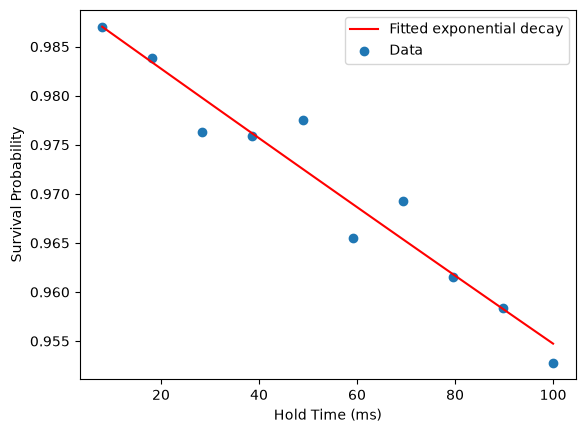

In [55]:
x_data = hold_time / 100
y_data = survival_list

# Fit an exponential decay model to the survival data
from scipy.optimize import curve_fit

def exp_decay(t, A, tau):
    return A * np.exp(-t / tau)

popt, _ = curve_fit(exp_decay, x_data, y_data, p0=[1.0, 3000])

xfit = np.linspace(min(x_data), max(x_data), 100)
yfit = exp_decay(xfit, *popt)

plt.plot(xfit, yfit, 'r-', label='Fitted exponential decay')
plt.scatter(x_data, y_data, label='Data')
plt.xlabel("Hold Time (ms)")
plt.ylabel("Survival Probability")
plt.legend()
print(f"Imaging survival probability: {popt[0]*100:.4f} %")

In [16]:
import os
import pickle

data_dir = "C:\\Users\\tweez\\Box\\Working folder\\caftweezers\\Data\\12Aug26"
dataset_title = "imaging_survival_50ms"

os.makedirs(os.path.join(data_dir, dataset_title), exist_ok=True)

# Save imgs1 and imgs2 to two pickle files, one called initial, one called final, and one called photon_data
with open(os.path.join(data_dir, dataset_title, "initial_imgs.pkl"), "wb") as f:
    pickle.dump(imgs1, f)
with open(os.path.join(data_dir, dataset_title, "final_imgs.pkl"), "wb") as f:
    pickle.dump(imgs2, f)


## Rearrangement Exp 1

In [25]:
threshold_count = an.convert_photons_to_counts(threshold_1)

In [41]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement
import time

coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]
await asyncio.to_thread(
    coordinator.initialise,
    data1, data2, array_shape1, array_shape2,
    d0=0.5, fps=1/(1e-6), threshold=threshold_count*1.1,
    grid_positions=grid_positions_1, profile="linear", window_size=5, feature_size=10, 
    detector=scorer
)

Occupancy via PSF detector (window 9, threshold 3.3).
Rearrangement node initialised.


In [42]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [44]:
N_iterations = 1000  # adjust before running
imgs_software = []
err_indices = []
timings_log = []

for it in range(N_iterations):
    print(f"Running experiment iteration {it+1} / {N_iterations}")
    rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))

    time.sleep(0.1)
    exp.start_motmaster_experiment({
                "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                "BackgroundDrop": 0})
    img0, img1, timings = await rearrangement_task
    print("Images acquired from rearrangement node.")

    if img1.sum() == 0:
        print(f"Empty image received at iteration {it+1}. Discarding...")
        err_indices.append(it)
    else:
        imgs_software.append([img0, img1])
        timings_log.append(timings)

mean_rearrangement_time_ms = np.mean([t['total_rearrangement_ms'] for t in timings_log])
mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
mean_nframes = np.mean([t['n_frames'] for t in timings_log])
mean_speed = mean_rearrangement_time_ms / mean_nframes
mean_calc_upload_speed = mean_calc_upload_time_ms / mean_nframes
print(f"Average total rearrangement time = {mean_rearrangement_time_ms:.2f} ms")
print(f"Average number of frames = {mean_nframes:.2f}")
print(f"Average total speed = {mean_speed:.2f} ms/frame")
print(f"Average calculation and upload speed = {mean_calc_upload_speed:.2f} ms/frame")

Running experiment iteration 1 / 1000
Rearrangement complete: 30 frames, 24.4483ms total (occupancy 0.1198ms, calculation+upload 24.3285ms).
Images acquired from rearrangement node.
Running experiment iteration 2 / 1000
Rearrangement complete: 22 frames, 18.6886ms total (occupancy 0.1204ms, calculation+upload 18.5682ms).
Images acquired from rearrangement node.
Running experiment iteration 3 / 1000
Rearrangement complete: 22 frames, 19.1417ms total (occupancy 0.1202ms, calculation+upload 19.0215ms).
Images acquired from rearrangement node.
Running experiment iteration 4 / 1000
Rearrangement complete: 26 frames, 21.7350ms total (occupancy 0.1180ms, calculation+upload 21.6170ms).
Images acquired from rearrangement node.
Running experiment iteration 5 / 1000
Rearrangement complete: 16 frames, 14.6887ms total (occupancy 0.1202ms, calculation+upload 14.5685ms).
Images acquired from rearrangement node.
Running experiment iteration 6 / 1000
Rearrangement complete: 22 frames, 19.2780ms total (

  calculation + upload:   3.55 ms fixed + 0.698 ms/frame (residual sd 0.310 ms)
                 total:   3.74 ms fixed + 0.698 ms/frame (residual sd 0.319 ms)

ratio total/n_frames = 0.875 ms/frame over n_frames 16-30


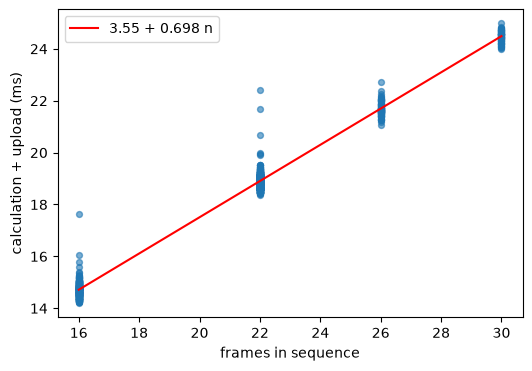

In [45]:
n_frames = np.array([t['n_frames'] for t in timings_log], dtype=float)
calc_upload_ms = np.array([t['calculation_and_upload_ms'] for t in timings_log])
total_ms = np.array([t['total_rearrangement_ms'] for t in timings_log])

if len(np.unique(n_frames)) < 2:
    print(f"All shots used {n_frames[0]:.0f} frames - cannot separate fixed from per-frame cost.")
else:
    for label, y in (("calculation + upload", calc_upload_ms), ("total", total_ms)):
        per_frame, fixed = np.polyfit(n_frames, y, 1)
        residual = y - (fixed + per_frame * n_frames)
        print(f"{label:>22}: {fixed:6.2f} ms fixed + {per_frame:.3f} ms/frame "
              f"(residual sd {residual.std():.3f} ms)")
    print(f"\nratio total/n_frames = {(calc_upload_ms / n_frames).mean():.3f} ms/frame "
          f"over n_frames {n_frames.min():.0f}-{n_frames.max():.0f}")

    plt.figure(figsize=(6, 4))
    plt.scatter(n_frames, calc_upload_ms, s=18, alpha=0.6)
    fit_x = np.array([n_frames.min(), n_frames.max()])
    per_frame, fixed = np.polyfit(n_frames, calc_upload_ms, 1)
    plt.plot(fit_x, fixed + per_frame * fit_x, 'r-',
             label=f"{fixed:.2f} + {per_frame:.3f} n")
    plt.xlabel("frames in sequence")
    plt.ylabel("calculation + upload (ms)")
    plt.legend()
    plt.show()

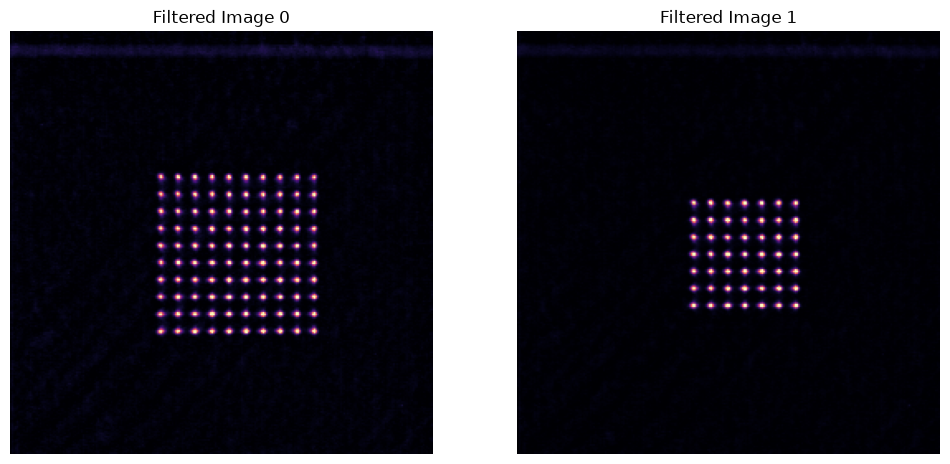

In [46]:
tot_imgs = np.array(imgs_software)

imgs0 = tot_imgs[:, 0, :, :]
imgs1 = tot_imgs[:, 1, :, :]

imgs0_mean = imgs0.mean(axis=0)
imgs1_mean = imgs1.mean(axis=0)

imgs0_mean_filtered = an.morphological_tophat_high_pass(imgs0_mean, feature_size=feature_size)
imgs1_mean_filtered = an.morphological_tophat_high_pass(imgs1_mean, feature_size=feature_size)

# Plot imgs0_mean_filtered and imgs1_mean_filtered side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(imgs0_mean_filtered, cmap='magma', vmax=0.6*imgs0_mean_filtered.max())
plt.title('Filtered Image 0')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgs1_mean_filtered, cmap='magma', vmax=0.6*imgs1_mean_filtered.max())
plt.title('Filtered Image 1')
plt.axis('off')

plt.show()

Looking for trap sites...
10x10 array detected.


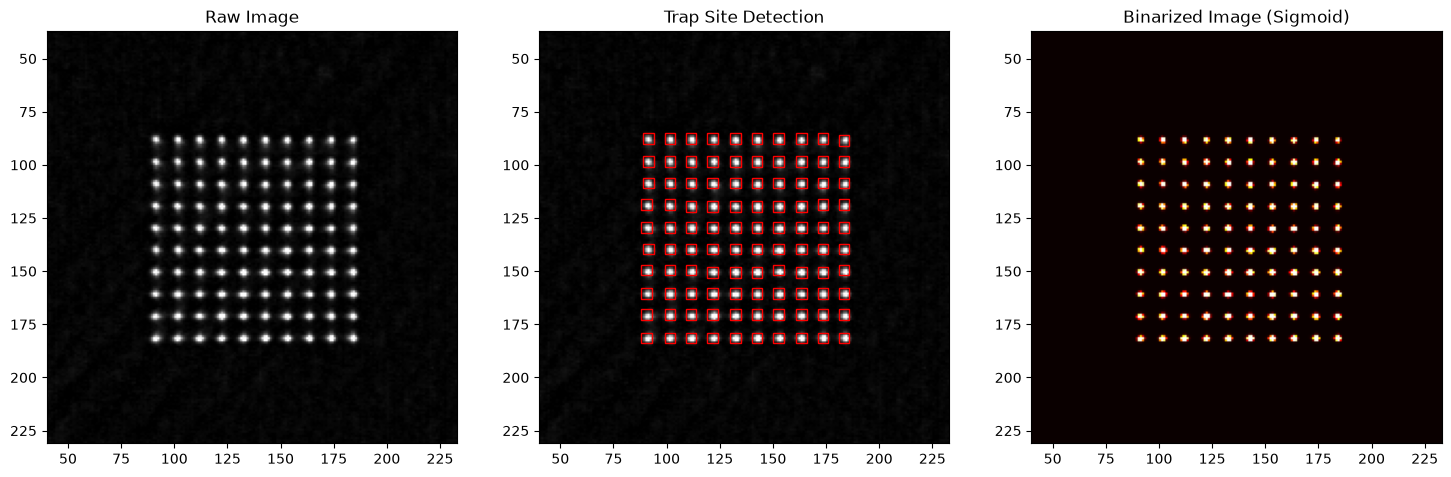

Trap (0, 0) Loading Probability : 55.50 %
Trap (0, 1) Loading Probability : 54.10 %
Trap (0, 2) Loading Probability : 57.10 %
Trap (0, 3) Loading Probability : 55.90 %
Trap (0, 4) Loading Probability : 53.90 %
Trap (0, 5) Loading Probability : 55.50 %
Trap (0, 6) Loading Probability : 52.80 %
Trap (0, 7) Loading Probability : 54.10 %
Trap (0, 8) Loading Probability : 49.00 %
Trap (0, 9) Loading Probability : 53.00 %
Trap (1, 0) Loading Probability : 56.00 %
Trap (1, 1) Loading Probability : 53.60 %
Trap (1, 2) Loading Probability : 55.60 %
Trap (1, 3) Loading Probability : 53.60 %
Trap (1, 4) Loading Probability : 55.30 %
Trap (1, 5) Loading Probability : 55.00 %
Trap (1, 6) Loading Probability : 55.10 %
Trap (1, 7) Loading Probability : 53.90 %
Trap (1, 8) Loading Probability : 57.10 %
Trap (1, 9) Loading Probability : 56.00 %
Trap (2, 0) Loading Probability : 55.40 %
Trap (2, 1) Loading Probability : 55.40 %
Trap (2, 2) Loading Probability : 55.00 %
Trap (2, 3) Loading Probability : 

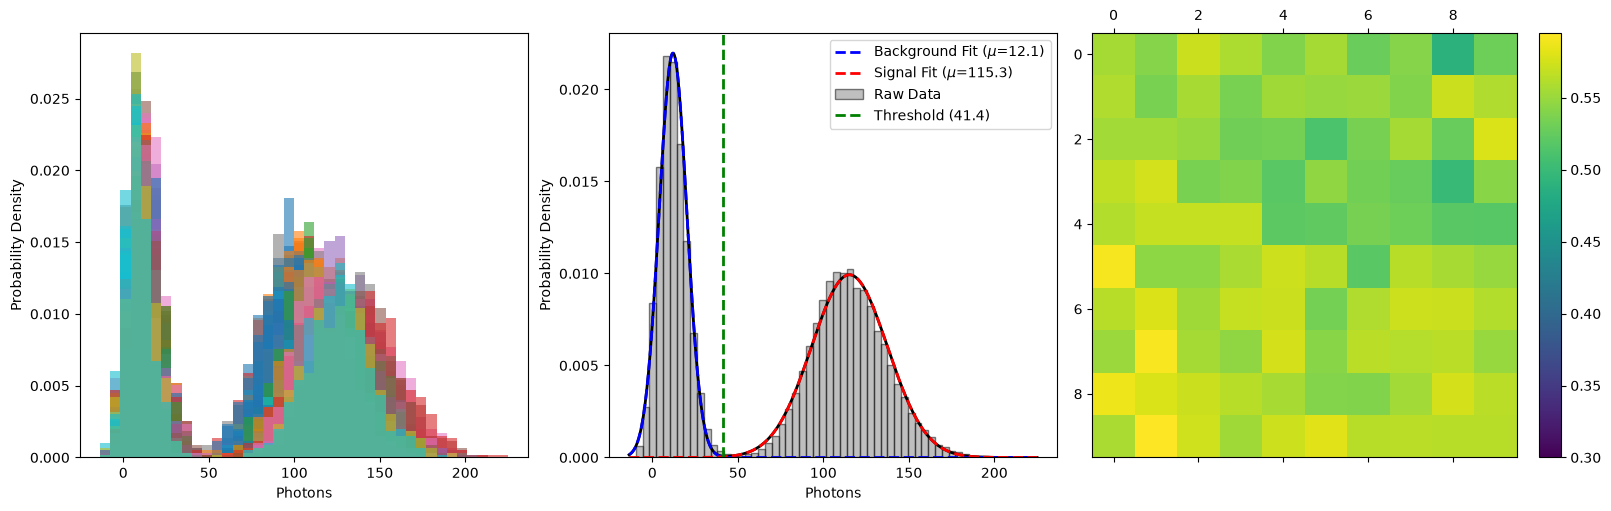

In [47]:
array_shape_1 = [10, 10]
window = 5
feature_size = 10

grid_positions_1, detection_threshold = an.detect_trap_sites(imgs0_mean_filtered, array_shape_1, detection_step=200)
an.visualize_results(imgs0_mean_filtered, grid_positions_1, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs0]
photon_rates, loading_probabilities, threshold_1, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_1, array_shape_1, threshold_detection=True, window_size=window, binning=60)

Looking for trap sites...
7x7 array detected.


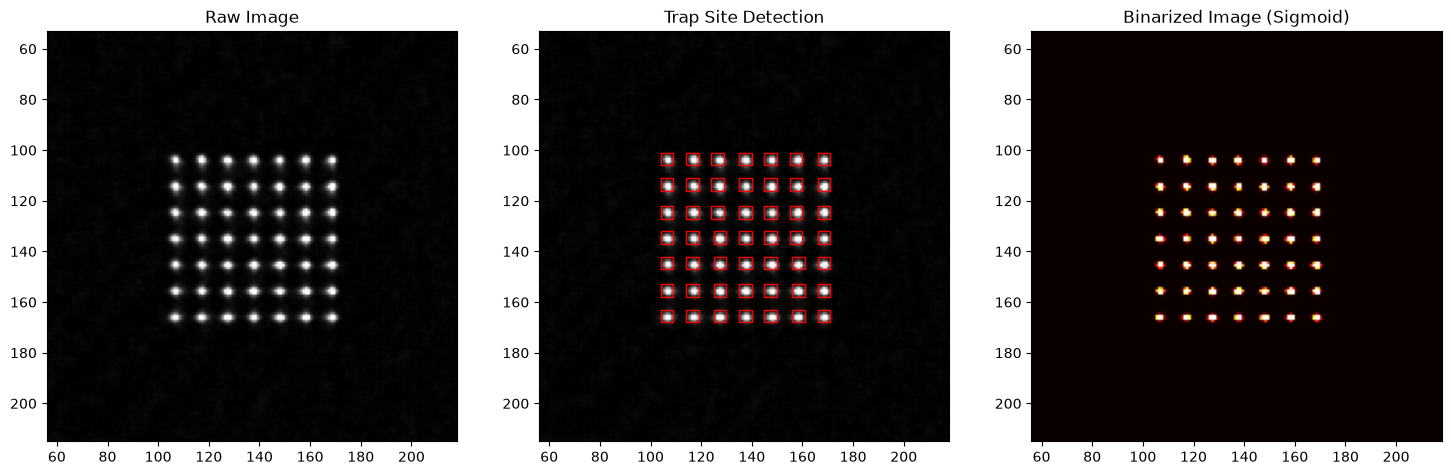

Trap (0, 0) Loading Probability : 96.80 %
Trap (0, 1) Loading Probability : 96.70 %
Trap (0, 2) Loading Probability : 96.80 %
Trap (0, 3) Loading Probability : 96.30 %
Trap (0, 4) Loading Probability : 96.80 %
Trap (0, 5) Loading Probability : 96.20 %
Trap (0, 6) Loading Probability : 96.50 %
Trap (1, 0) Loading Probability : 97.40 %
Trap (1, 1) Loading Probability : 96.40 %
Trap (1, 2) Loading Probability : 96.00 %
Trap (1, 3) Loading Probability : 94.70 %
Trap (1, 4) Loading Probability : 94.50 %
Trap (1, 5) Loading Probability : 95.60 %
Trap (1, 6) Loading Probability : 97.30 %
Trap (2, 0) Loading Probability : 96.60 %
Trap (2, 1) Loading Probability : 97.20 %
Trap (2, 2) Loading Probability : 95.00 %
Trap (2, 3) Loading Probability : 93.80 %
Trap (2, 4) Loading Probability : 94.50 %
Trap (2, 5) Loading Probability : 96.70 %
Trap (2, 6) Loading Probability : 95.80 %
Trap (3, 0) Loading Probability : 96.00 %
Trap (3, 1) Loading Probability : 96.30 %
Trap (3, 2) Loading Probability : 

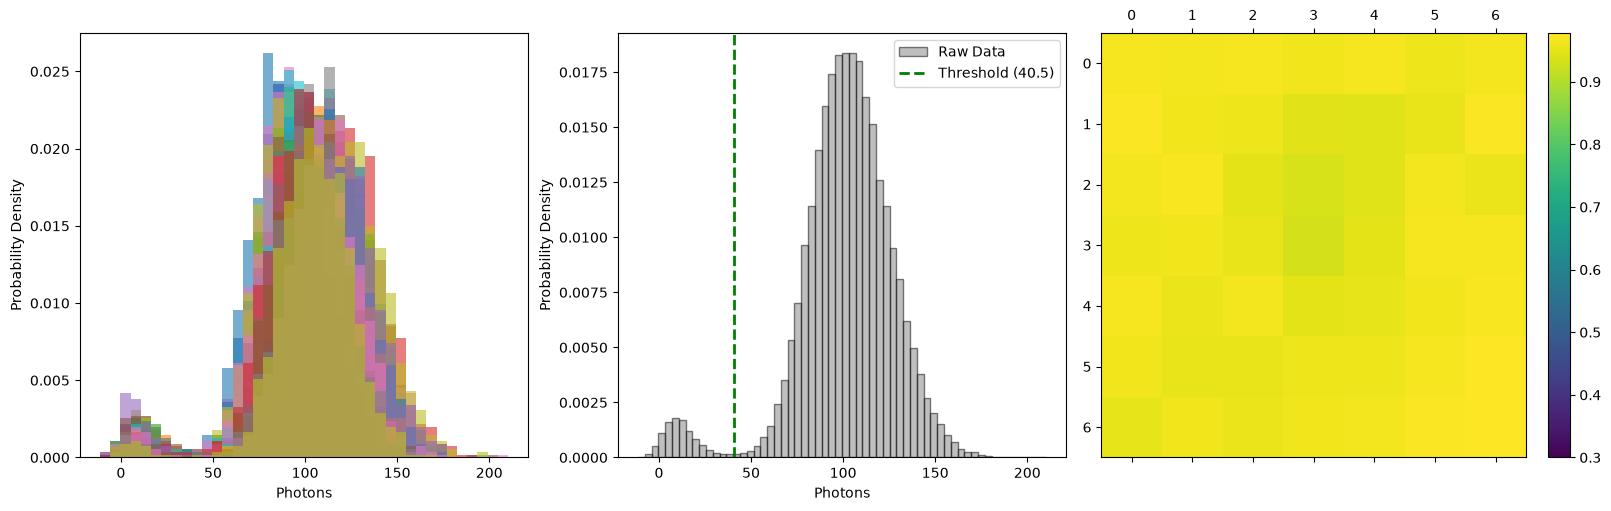

In [48]:
array_shape_2 = [7, 7]
window = 5
feature_size = 10

grid_positions_2, detection_threshold = an.detect_trap_sites(imgs1_mean_filtered, array_shape_2, detection_step=200)
an.visualize_results(imgs1_mean_filtered, grid_positions_2, margin=50, window_size=window, threshold=detection_threshold, vmaxfactor=0.5, bin_sharpness=20, bin_thresh_factor=0.7)

imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
photon_rates, loading_probabilities, _, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, array_shape_2, threshold_detection=False, threshold=threshold_2, window_size=window, binning=60)

In [49]:
loading_probabilities.mean() / baseline_survival_probability

np.float64(0.991429624157994)

In [ ]:
tot_rearrangement_times = np.array([t['total_rearrangement_ms'] for t in timings_log])
calc_upload_times = np.array([t['calculation_and_upload_ms'] for t in timings_log])
occupancy_extraction_times = np.array([t['occupancy_extraction_ms'] for t in timings_log])
n_frames = np.array([t['n_frames'] for t in timings_log])

dataset_title = "rearrangement_10x10_7x7"

os.makedirs(os.path.join(data_dir, dataset_title), exist_ok=True)

# Save tot_rearrangement_times, calc_upload_times, occupancy_extraction_times, n_frames, imgs0, imgs1 to a pickle file
with open(os.path.join(data_dir, dataset_title, "timing_and_images.pkl"), "wb") as f:
    pickle.dump({
        "tot_rearrangement_times": tot_rearrangement_times,
        "calc_upload_times": calc_upload_times,
        "occupancy_extraction_times": occupancy_extraction_times,
        "n_frames": n_frames,
        "imgs0": imgs0,
        "imgs1": imgs1
    }, f)

In [53]:
# Save contextual information about the experiment to a text file
with open(os.path.join(data_dir, dataset_title, "experiment_info.txt"), "w") as f:
    f.write(f"Dataset Title: {dataset_title}\n")
    f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"""
    50 ms time slot given for rearrangement with a baseline survival probability of {baseline_survival_probability:.6f}.
    Rearrangement parameters: d0 = 0.5, threshold = {threshold_count*1.1:.4f} photons, profile = linear, window_size = 5, feature_size = 10.
    Occupancy extraction using the PSF method.
    """)

In [52]:
# Create a subdirectory called intial images and one for final images
os.makedirs(os.path.join(data_dir, dataset_title, "initial_images"), exist_ok=True)
os.makedirs(os.path.join(data_dir, dataset_title, "final_images"), exist_ok=True)

# Save the initial and final images to the respective directories as .tif files
import tifffile

for i, img in enumerate(imgs0):
    tifffile.imwrite(os.path.join(data_dir, dataset_title, "initial_images", f"initial_img_{i:04d}.tif"), img)

for i, img in enumerate(imgs1):
    tifffile.imwrite(os.path.join(data_dir, dataset_title, "final_images", f"final_img_{i:04d}.tif"), img)

---

## Rearrangement Exp 2

In [ ]:
import asyncio
from pytweezer.coordinators.rearrangement import Rearrangement
import time

coordinator = Rearrangement({"camera": hamcam, "slm": slm, "phasemask_generator": PM}, {})

data1, array_shape1 = np.stack(terms1[:4]), terms1[4]
data2, array_shape2 = np.stack(terms2[:4]), terms2[4]

Occupancy via PSF detector (window 9, threshold 3.3).
Rearrangement node initialised.


In [55]:
# Experiment and camera setup
n_iterations = 1
exp.set_motmaster_experiment("RbTweezerBasic2026_2")
exp.set_iterations(n_iterations)
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)

{'ok': True,
 'command': 'interface_method',
 'method': 'set_run_until_stopped',
 'state': 'accepted'}

In [56]:
N_iterations = 200  # adjust before running

step_sizes = np.linspace(0.5, 2.0, 10)

img_data = []
timing_data = []

for d0 in step_sizes:
    await asyncio.to_thread(
        coordinator.initialise,
        data1, data2, array_shape1, array_shape2,
        d0=d0, fps=1/(1e-6), threshold=threshold_count*1.1,
        grid_positions=grid_positions_1, profile="linear", window_size=5, feature_size=10, 
        detector=scorer
    )

    imgs_software = []
    err_indices = []
    timings_log = []

    for it in range(N_iterations):
        print(f"Running experiment iteration {it+1} / {N_iterations}")
        rearrangement_task = asyncio.create_task(asyncio.to_thread(coordinator.arm_rearrangement))

        time.sleep(0.1)
        exp.start_motmaster_experiment({
                    "tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                    "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"),
                    "tMolCoolVCO1": ExpParams.get_parameter("tMolCoolVCO1"), "tMolRepVCO1": ExpParams.get_parameter("tMolRepVCO1"), 
                    "tMolCoolVVA1": ExpParams.get_parameter("tMolCoolVVA1"), "tMolRepVVA1": ExpParams.get_parameter("tMolRepVVA1"),
                    "tMolCoolVCO2": ExpParams.get_parameter("tMolCoolVCO2"), "tMolRepVCO2": ExpParams.get_parameter("tMolRepVCO2"), 
                    "tMolCoolVVA2": ExpParams.get_parameter("tMolCoolVVA2"), "tMolRepVVA2": ExpParams.get_parameter("tMolRepVVA2"),
                    "tImgCoolVCO1": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA1": ExpParams.get_parameter("tImgCoolVVA"), 
                    "tImgCoolVCO2": ExpParams.get_parameter("tImgCoolVCO"), "tImgCoolVVA2": ExpParams.get_parameter("tImgCoolVVA"),
                    "tMOTShimXccValue": ExpParams.get_parameter("tMOTShimXccValue"), "tMOTShimYccValue": ExpParams.get_parameter("tMOTShimYccValue"), "tMOTShimZccValue": ExpParams.get_parameter("tMOTShimZccValue"),
                    "BackgroundDrop": 0})
        img0, img1, timings = await rearrangement_task
        print("Images acquired from rearrangement node.")

        if img1.sum() == 0:
            print(f"Empty image received at iteration {it+1}. Discarding...")
            err_indices.append(it)
        else:
            imgs_software.append([img0, img1])
            timings_log.append(timings)

    mean_rearrangement_time_ms = np.mean([t['total_rearrangement_ms'] for t in timings_log])
    mean_calc_upload_time_ms = np.mean([t['calculation_and_upload_ms'] for t in timings_log])
    mean_nframes = np.mean([t['n_frames'] for t in timings_log])
    mean_speed = mean_rearrangement_time_ms / mean_nframes
    mean_calc_upload_speed = mean_calc_upload_time_ms / mean_nframes

    timing_data.append(timings_log)
    img_data.append(imgs_software)

    print(f"d0 = {d0:.2f}: Average total rearrangement time = {mean_rearrangement_time_ms:.2f} ms, Average number of frames = {mean_nframes:.2f}, Average total speed = {mean_speed:.2f} ms/frame, Average calculation and upload speed = {mean_calc_upload_speed:.2f} ms/frame")

Occupancy via PSF detector (window 9, threshold 3.3).
Rearrangement node initialised.
Running experiment iteration 1 / 200
Rearrangement complete: 22 frames, 19.5373ms total (occupancy 0.3314ms, calculation+upload 19.2059ms).
Images acquired from rearrangement node.
Running experiment iteration 2 / 200
Rearrangement complete: 22 frames, 18.8987ms total (occupancy 0.1618ms, calculation+upload 18.7369ms).
Images acquired from rearrangement node.
Running experiment iteration 3 / 200
Rearrangement complete: 16 frames, 14.6490ms total (occupancy 0.1354ms, calculation+upload 14.5136ms).
Images acquired from rearrangement node.
Running experiment iteration 4 / 200
Rearrangement complete: 16 frames, 14.9878ms total (occupancy 0.1370ms, calculation+upload 14.8508ms).
Images acquired from rearrangement node.
Running experiment iteration 5 / 200
Rearrangement complete: 16 frames, 14.5521ms total (occupancy 0.1332ms, calculation+upload 14.4189ms).
Images acquired from rearrangement node.
Running e

In [59]:
rearrangement_efficiencies = []
for i, d0 in enumerate(step_sizes):
    tot_imgs = np.array(img_data[i])
    imgs0 = tot_imgs[:, 0, :, :]
    imgs1 = tot_imgs[:, 1, :, :]    
    imgs_filtered = [an.morphological_tophat_high_pass(img, feature_size=feature_size) for img in imgs1]
    photon_rates, loading_probabilities, _, fidelity = an.get_array_loading_statistics(imgs_filtered, grid_positions_2, array_shape_2, threshold_detection=False, threshold=threshold_2, window_size=window, binning=60, show_histogram=False, verbose=False)
    filling_fraction = np.mean(loading_probabilities)
    rearrangement_efficiency = filling_fraction / baseline_survival_probability
    print(f"d0 = {d0:.2f}: Filling fraction = {filling_fraction:.4f}, Rearrangement efficiency = {rearrangement_efficiency:.4f}")
    rearrangement_efficiencies.append(rearrangement_efficiency)

d0 = 0.50: Filling fraction = 0.9619, Rearrangement efficiency = 0.9920
d0 = 0.67: Filling fraction = 0.9616, Rearrangement efficiency = 0.9917
d0 = 0.83: Filling fraction = 0.9657, Rearrangement efficiency = 0.9959
d0 = 1.00: Filling fraction = 0.9604, Rearrangement efficiency = 0.9904
d0 = 1.17: Filling fraction = 0.9550, Rearrangement efficiency = 0.9848
d0 = 1.33: Filling fraction = 0.9283, Rearrangement efficiency = 0.9573
d0 = 1.50: Filling fraction = 0.9249, Rearrangement efficiency = 0.9538
d0 = 1.67: Filling fraction = 0.8666, Rearrangement efficiency = 0.8937
d0 = 1.83: Filling fraction = 0.8111, Rearrangement efficiency = 0.8365
d0 = 2.00: Filling fraction = 0.7735, Rearrangement efficiency = 0.7976


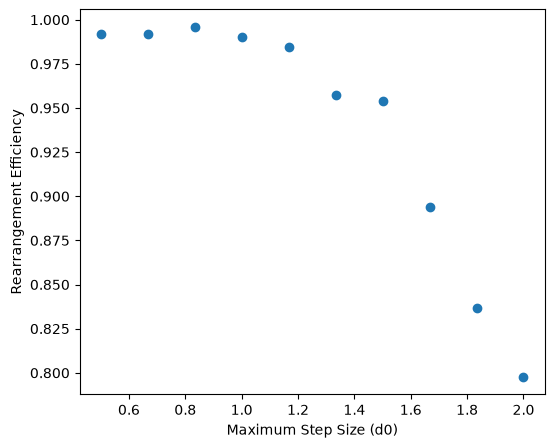

In [83]:
from scipy.optimize import curve_fit

x_data = step_sizes
y_data = rearrangement_efficiencies

plt.figure(figsize=(6, 5))
plt.scatter(x_data, y_data)
plt.xlabel("Maximum Step Size (d0)")
plt.ylabel("Rearrangement Efficiency")
plt.show()

In [67]:
n_frames_data = []
calc_upload_time_data = []
total_rearrangement_time_data = []
for i, d0 in enumerate(step_sizes):
    timings_log = timing_data[i]
    for t in timings_log:
        n_frames = t['n_frames']
        calc_upload_time = t['calculation_and_upload_ms']
        tot_rearrangement_time = t['total_rearrangement_ms']
        n_frames_data.append(n_frames)
        calc_upload_time_data.append(calc_upload_time)
        total_rearrangement_time_data.append(tot_rearrangement_time)

  calculation + upload:   3.48 ms fixed + 0.699 ms/frame (residual sd 0.237 ms)
                 total:   3.68 ms fixed + 0.698 ms/frame (residual sd 0.245 ms)

ratio total/n_frames = 1.122 ms/frame over n_frames 4-30


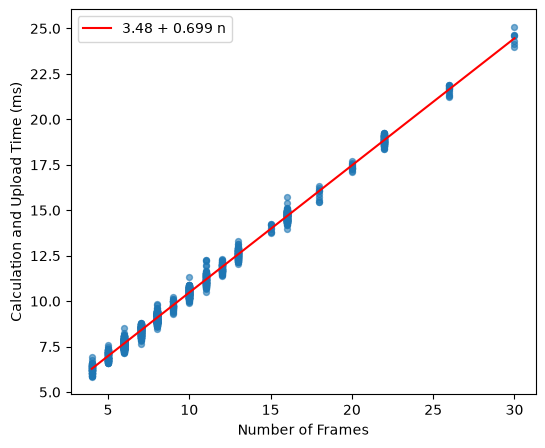

In [82]:
n_frames = np.array(n_frames_data)
calc_upload_ms = np.array(calc_upload_time_data)
total_ms = np.array(total_rearrangement_time_data)

if len(np.unique(n_frames)) < 2:
    print(f"All shots used {n_frames[0]:.0f} frames - cannot separate fixed from per-frame cost.")
else:
    for label, y in (("calculation + upload", calc_upload_ms), ("total", total_ms)):
        per_frame, fixed = np.polyfit(n_frames, y, 1)
        residual = y - (fixed + per_frame * n_frames)
        print(f"{label:>22}: {fixed:6.2f} ms fixed + {per_frame:.3f} ms/frame "
              f"(residual sd {residual.std():.3f} ms)")
    print(f"\nratio total/n_frames = {(calc_upload_ms / n_frames).mean():.3f} ms/frame "
          f"over n_frames {n_frames.min():.0f}-{n_frames.max():.0f}")

    plt.figure(figsize=(6, 5))
    plt.scatter(n_frames, calc_upload_ms, s=18, alpha=0.6)
    fit_x = np.array([n_frames.min(), n_frames.max()])
    per_frame, fixed = np.polyfit(n_frames, calc_upload_ms, 1)
    plt.plot(fit_x, fixed + per_frame * fit_x, 'r-',
             label=f"{fixed:.2f} + {per_frame:.3f} n")
             
    plt.xlabel("Number of Frames")
    plt.ylabel("Calculation and Upload Time (ms)")
    plt.legend()
    plt.show()

Fit parameters: per_frame_time = 0.699 ± 0.001 ms/frame, fixed_time = 3.48 ± 0.01 ms


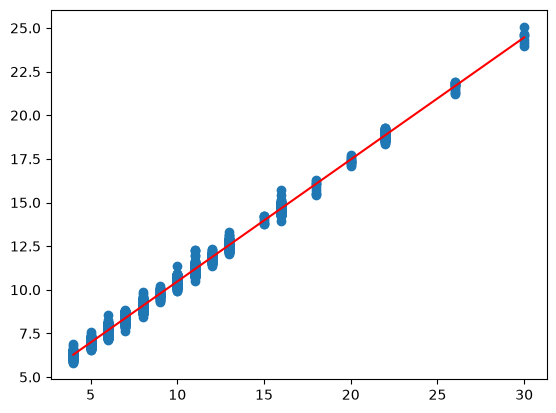

In [85]:
x_data = n_frames
y_data = calc_upload_ms

lin_fit = lambda x, m, b: m * x + b

popt, pcov = curve_fit(lin_fit, x_data, y_data)
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = lin_fit(x_fit, *popt)
plt.scatter(x_data, y_data, label='Data')
plt.plot(x_fit, y_fit, 'r-', label=f'Fit: y = {popt[0]:.3f}x + {popt[1]:.2f}')

# Print the fit parameters and their uncertainties
per_frame_time = popt[0]
fixed_time = popt[1]
per_frame_time_err = np.sqrt(pcov[0][0])
fixed_time_err = np.sqrt(pcov[1][1])
print(f"Fit parameters: per_frame_time = {per_frame_time:.3f} ± {per_frame_time_err:.3f} ms/frame, fixed_time = {fixed_time:.2f} ± {fixed_time_err:.2f} ms")

In [86]:
dataset_dir = os.path.join(data_dir, "rearrangement_step_size_scans")
for i, d0 in enumerate(step_sizes):
    dataset_title = f"rearrangement_d0_{d0:.2f}"
    os.makedirs(os.path.join(dataset_dir, dataset_title), exist_ok=True)

    # Save timing_data and img_data to a pickle file
    with open(os.path.join(dataset_dir, dataset_title, "timing_and_images.pkl"), "wb") as f:
        pickle.dump({
            "timing_data": timing_data[i],
            "img_data": img_data[i]
        }, f)

    # Save contextual information about the experiment to a text file
    with open(os.path.join(dataset_dir, dataset_title, "experiment_info.txt"), "w") as f:
        f.write(f"Dataset Title: {dataset_title}\n")
        f.write(f"Date: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"""
        Rearrangement parameters: d0 = {d0:.2f}, threshold = {threshold_count*1.1:.4f} photons, profile = linear, window_size = 5, feature_size = 10.
        Occupancy extraction using the PSF method.
        """)

---

In [87]:
hamcam.close()
slm.close()
motcam.close()

ImagEM X2 camera closed.
SLM 1 closed.
Thorlabs TLCamera - motcam - closed.
